In [1]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer

# Handling imbalance
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Save model
import joblib

In [2]:
df = pd.read_csv('/content/diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [4]:
# Check missing values
df.isnull().sum()

# Fill numeric with median
num_cols = df.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

# Fill categorical with most frequent
cat_cols = df.select_dtypes(include='object').columns
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

In [5]:
df = df.drop_duplicates()

In [6]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [7]:
X = df.drop('diabetes', axis=1)   # target column
y = df['diabetes']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
lr = LogisticRegression(max_iter=5000)

param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(lr, param_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)

lr_best = grid_lr.best_estimator_

y_pred_lr = lr_best.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

         0.0       0.99      0.89      0.94     17534
         1.0       0.43      0.87      0.58      1696

    accuracy                           0.89     19230
   macro avg       0.71      0.88      0.76     19230
weighted avg       0.94      0.89      0.90     19230



In [12]:
rf = RandomForestClassifier()

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, param_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

rf_best = grid_rf.best_estimator_

y_pred_rf = rf_best.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98     17534
         1.0       0.83      0.73      0.77      1696

    accuracy                           0.96     19230
   macro avg       0.90      0.86      0.88     19230
weighted avg       0.96      0.96      0.96     19230



In [14]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Faster SVM model
svm = LinearSVC(max_iter=5000)

# Small parameter grid for speed
param_svm = {
    'C': [0.1, 1, 10]
}

# Grid Search
grid_svm = GridSearchCV(
    svm,
    param_svm,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

# Train model
grid_svm.fit(X_train, y_train)

# Best model
svm_best = grid_svm.best_estimator_

# Prediction
y_pred_svm = svm_best.predict(X_test)

# Evaluation
print("Fast SVM Model")
print(classification_report(y_test, y_pred_svm))

Fast SVM Model
              precision    recall  f1-score   support

         0.0       0.99      0.89      0.93     17534
         1.0       0.43      0.87      0.58      1696

    accuracy                           0.89     19230
   macro avg       0.71      0.88      0.76     19230
weighted avg       0.94      0.89      0.90     19230



In [15]:
dt = DecisionTreeClassifier()

param_dt = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(dt, param_dt, cv=5, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train, y_train)

dt_best = grid_dt.best_estimator_

y_pred_dt = dt_best.predict(X_test)

print("Decision Tree")
print(classification_report(y_test, y_pred_dt))

Decision Tree
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98     17534
         1.0       0.80      0.72      0.76      1696

    accuracy                           0.96     19230
   macro avg       0.89      0.85      0.87     19230
weighted avg       0.96      0.96      0.96     19230



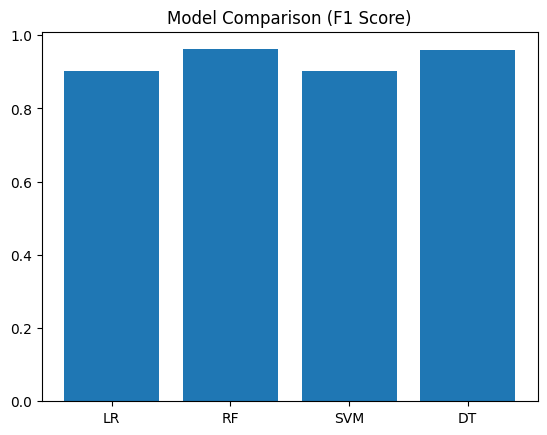

In [16]:
models = ['LR', 'RF', 'SVM', 'DT']

f1_scores = [
    classification_report(y_test, y_pred_lr, output_dict=True)['weighted avg']['f1-score'],
    classification_report(y_test, y_pred_rf, output_dict=True)['weighted avg']['f1-score'],
    classification_report(y_test, y_pred_svm, output_dict=True)['weighted avg']['f1-score'],
    classification_report(y_test, y_pred_dt, output_dict=True)['weighted avg']['f1-score']
]

plt.bar(models, f1_scores)
plt.title("Model Comparison (F1 Score)")
plt.show()

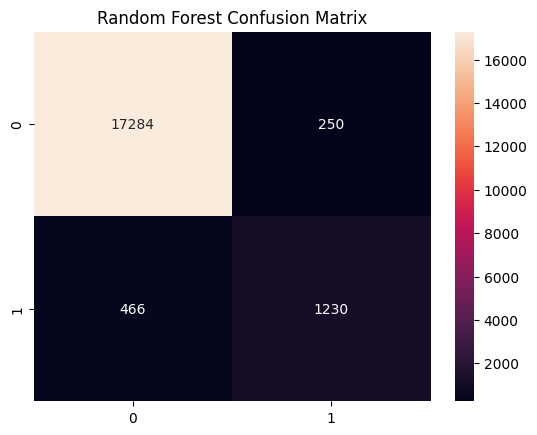

In [17]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

In [18]:
joblib.dump(rf_best, 'disease_prediction_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']